# 03 描述性统计、可视化与 CAPM 回归

本 Notebook 基于清洗合并后的 CSV 数据进行分析，输出描述性统计表、图形和 CAPM 回归结果，并提供可直接阅读的文字解读。


In [1]:
from pathlib import Path
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

ROOT = Path.cwd()
OUTPUT = ROOT / "output"
OUTPUT.mkdir(exist_ok=True)

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Microsoft YaHei")

combined = pd.read_csv(ROOT / "data/combined/combined_data.csv")
combined["date"] = pd.to_datetime(combined["date"])
stock_info = pd.read_csv(ROOT / "data/stock_list.csv")
finance = pd.read_csv(ROOT / "data/finance/finance_ratios.csv")

combined.head()


,date,code,name,open,close,high,low,volume,amount,source,return,is_extreme,industry,hs300_close,hs300_return,zz500_close,zz500_return,month,cpi,m2
0,2020-01-02,1,平安银行,2161.80,2189.30,2199.30,2149.29,1530232.0,2.571196e+09,akshare,NaN,False,银行,4152.241,NaN,5366.138,NaN,2020-01,4.5,8.7
1,2020-01-03,1,平安银行,2198.05,2228.06,2244.31,2195.55,1116195.0,1.914495e+09,akshare,0.017549,False,银行,4144.965,-0.001754,5380.637,0.002698,2020-01,4.5,8.7
2,2020-01-06,1,平安银行,2206.80,2214.31,2248.06,2194.30,862084.0,1.477930e+09,akshare,-0.006190,False,银行,4129.295,-0.003788,5434.850,0.010025,2020-01,4.5,8.7
3,2020-01-07,1,平安银行,2221.81,2224.31,2240.56,2199.30,728608.0,1.247047e+09,akshare,0.004506,False,银行,4160.227,0.007463,5499.840,0.011887,2020-01,4.5,8.7
4,2020-01-08,1,平安银行,2205.55,2163.05,2211.80,2159.30,847824.0,1.423609e+09,akshare,-0.027927,False,银行,4112.317,-0.011583,5423.797,-0.013923,2020-01,4.5,8.7


## 4.1 基本统计量

日收益率使用对数收益率，年化均值乘以 252，年化波动率乘以 `sqrt(252)`，最大回撤基于累计净值计算。


In [2]:
def max_drawdown(ret: pd.Series) -> float:
    wealth = np.exp(ret.fillna(0).cumsum())
    drawdown = wealth / wealth.cummax() - 1
    return drawdown.min()


stats_records = []
for code_value, group in combined.sort_values("date").groupby("code"):
    ret = group["return"].dropna()
    meta = stock_info.loc[stock_info["code"].astype(str).str.zfill(6) == str(code_value).zfill(6)].iloc[0]
    stats_records.append({
        "股票": meta["name"],
        "代码": str(code_value).zfill(6),
        "行业": meta["industry"],
        "年化均值": ret.mean() * 252,
        "年化波动率": ret.std() * math.sqrt(252),
        "偏度": ret.skew(),
        "峰度": ret.kurt(),
        "最大回撤": max_drawdown(ret),
    })

desc_stats = pd.DataFrame(stats_records)
desc_stats.to_csv(ROOT / "output/descriptive_stats.csv", index=False, encoding="utf-8-sig")
desc_stats


,股票,代码,行业,年化均值,年化波动率,偏度,峰度,最大回撤
0,平安银行,000001,银行,-0.036791,0.265626,0.366956,4.588470,-0.593755
1,中兴通讯,000063,通讯,0.018865,0.425718,0.309410,2.445436,-0.618668
2,五粮液,000858,白酒,-0.027287,0.315906,0.007888,3.399582,-0.666227
3,比亚迪,002594,汽车,0.298240,0.431090,0.308524,2.105598,-0.525353
4,招商银行,600036,银行,0.032078,0.231882,0.261592,3.564639,-0.453004
5,贵州茅台,600519,白酒,0.049910,0.255815,0.199471,3.538868,-0.451789
6,长江电力,600900,能源,0.097153,0.178075,0.365532,3.531617,-0.175399
7,中国移动,600941,通讯,0.171986,0.249081,0.606050,5.035782,-0.192001
8,长城汽车,601633,汽车,0.134685,0.448674,0.458536,2.194462,-0.706053
9,中国石油,601857,能源,0.157906,0.292828,0.206582,5.083190,-0.325359


统计表用于比较不同股票的收益风险特征。年化收益和波动率体现收益补偿与风险暴露，最大回撤则更直观地衡量持有期间可能承受的下行压力。


## 图 1：归一化收盘价走势图

将每个资产的起点标准化为 1，可以比较不同价格水平股票的相对走势。


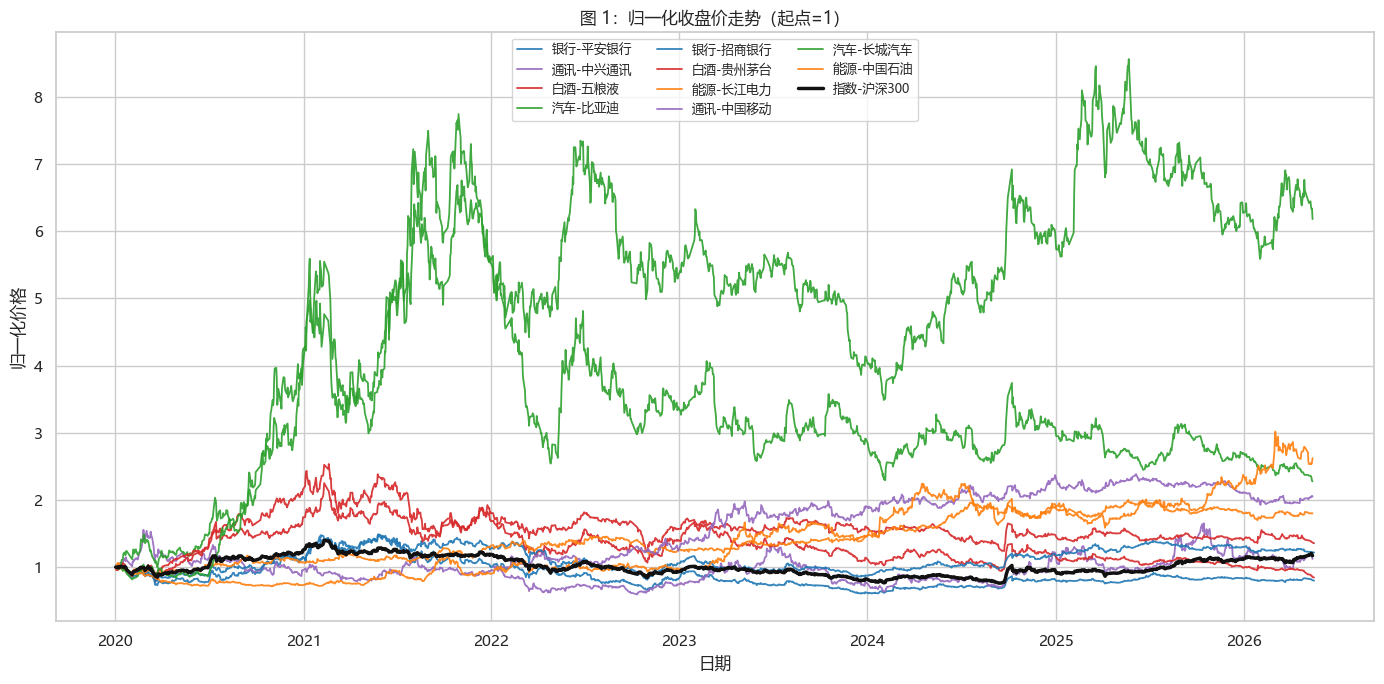

In [3]:
industry_palette = {
    "银行": "#1f77b4", "白酒": "#d62728", "汽车": "#2ca02c",
    "能源": "#ff7f0e", "通讯": "#9467bd", "指数": "#111111",
}

price_wide = combined.pivot_table(index="date", columns="code", values="close", aggfunc="last").sort_index()
norm_prices = price_wide / price_wide.apply(lambda s: s.dropna().iloc[0])
hs300 = combined.drop_duplicates("date").set_index("date")["hs300_close"].sort_index()
hs300_norm = hs300 / hs300.dropna().iloc[0]

fig, ax = plt.subplots(figsize=(14, 7))
for code_value in norm_prices.columns:
    meta = stock_info.loc[stock_info["code"].astype(str).str.zfill(6) == str(code_value).zfill(6)].iloc[0]
    ax.plot(norm_prices.index, norm_prices[code_value], lw=1.3, alpha=0.9, color=industry_palette[meta["industry"]], label=f"{meta['industry']}-{meta['name']}")
ax.plot(hs300_norm.index, hs300_norm, color=industry_palette["指数"], lw=2.5, label="指数-沪深300")
ax.set_title("图 1：归一化收盘价走势（起点=1）")
ax.set_xlabel("日期")
ax.set_ylabel("归一化价格")
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT / "fig1_normalized_prices.png", dpi=180)
plt.show()


图 1 展示了不同股票相对于起点的累计表现。若某只股票曲线长期高于沪深 300，说明其在样本期内获得了更强的相对收益；若曲线波动幅度更大，则说明该股票承担了更高的价格风险。


## 图 2：日收益率分布图


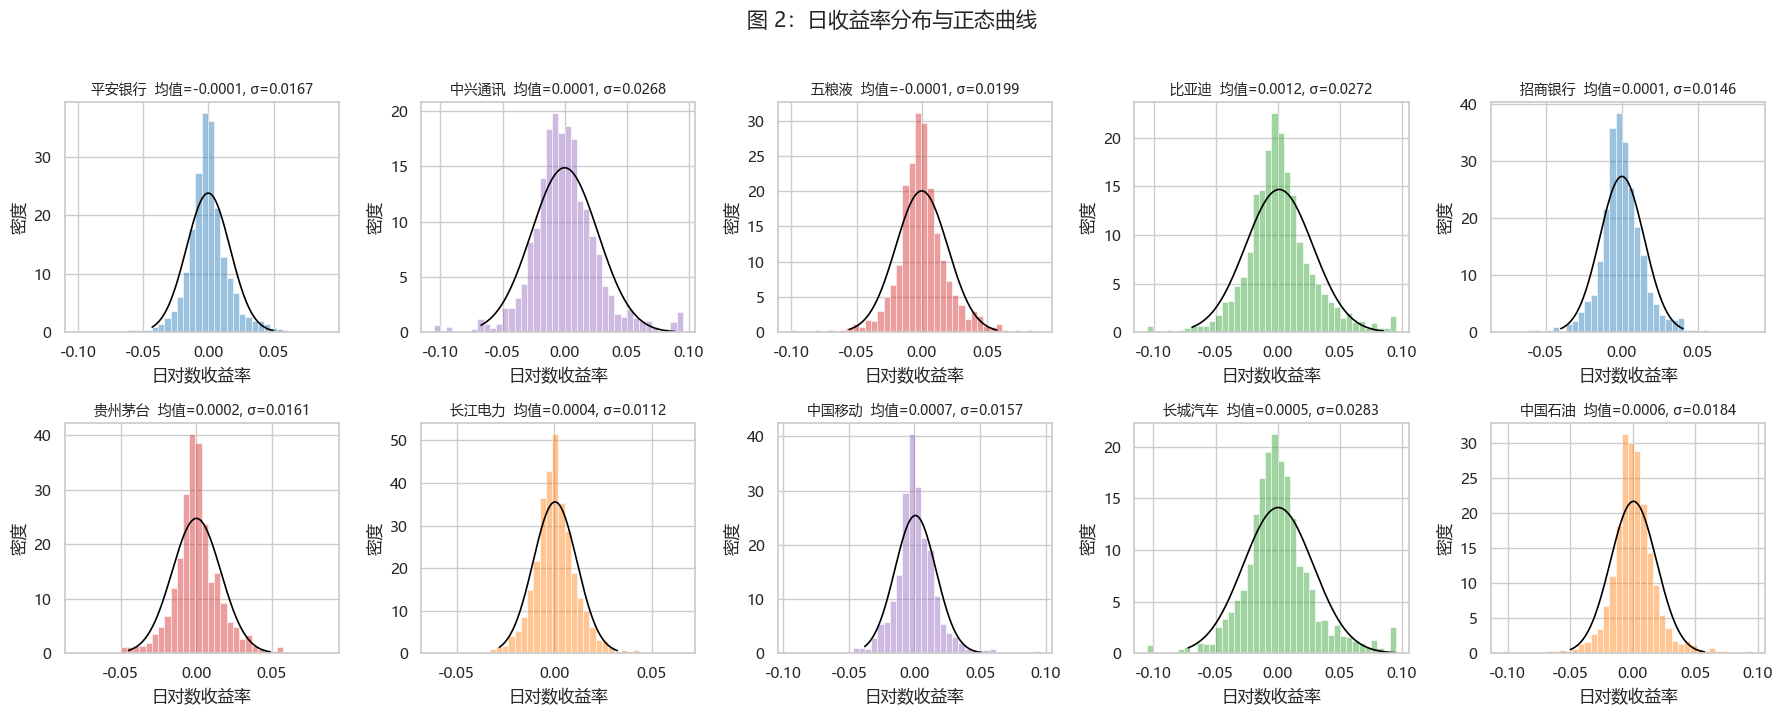

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=False, sharey=False)
for ax, (code_value, group) in zip(axes.ravel(), combined.groupby("code")):
    meta = stock_info.loc[stock_info["code"].astype(str).str.zfill(6) == str(code_value).zfill(6)].iloc[0]
    ret = group["return"].dropna()
    sns.histplot(ret, bins=40, stat="density", color=industry_palette[meta["industry"]], alpha=0.45, ax=ax)
    x = np.linspace(ret.quantile(0.01), ret.quantile(0.99), 200)
    ax.plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), color="black", lw=1.2)
    ax.set_title(f"{meta['name']}  均值={ret.mean():.4f}, σ={ret.std():.4f}", fontsize=10)
    ax.set_xlabel("日对数收益率")
    ax.set_ylabel("密度")
fig.suptitle("图 2：日收益率分布与正态曲线", y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(OUTPUT / "fig2_return_distribution.png", dpi=180, bbox_inches="tight")
plt.show()


图 2 可以观察收益率是否接近正态分布。实际股票收益常出现尖峰厚尾，说明极端波动发生概率往往高于简单正态假设，这也是风险管理中需要额外关注的部分。


## 图 3：收益率相关系数热力图


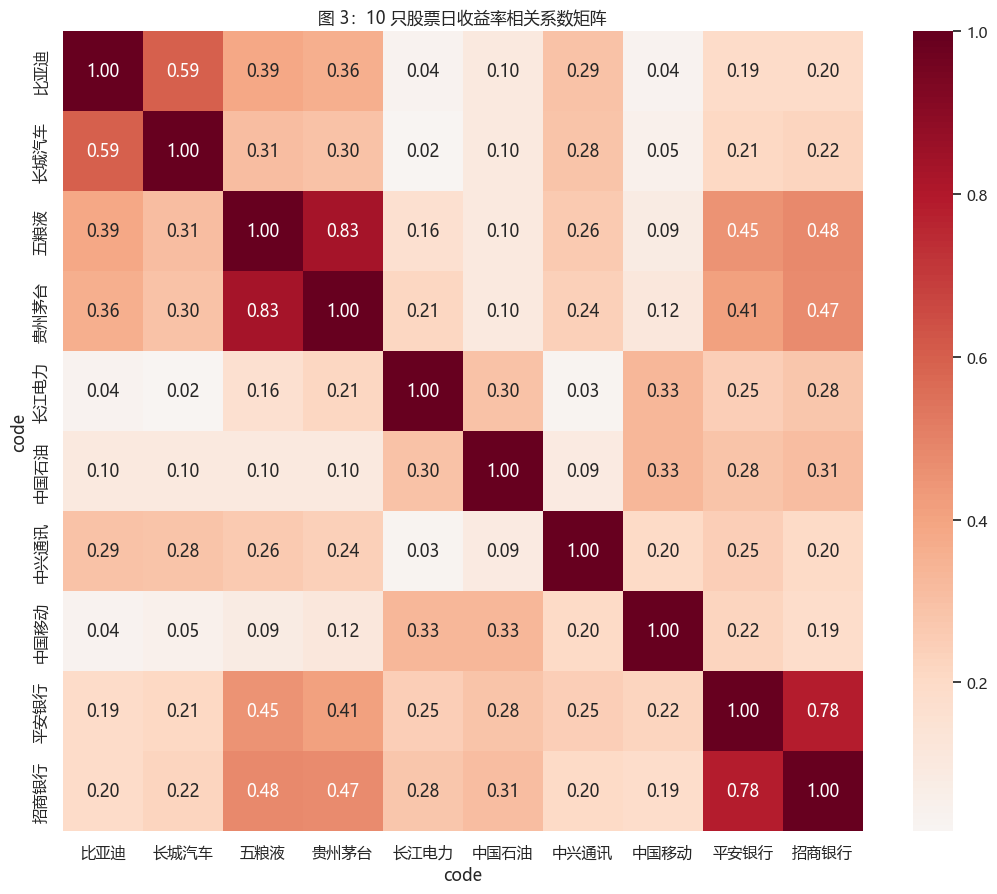

In [5]:
ordered_codes = stock_info.sort_values(["industry", "code"])["code"].astype(str).str.zfill(6).tolist()
ret_wide = combined.pivot_table(index="date", columns="code", values="return", aggfunc="last")
ret_wide.columns = ret_wide.columns.astype(str).str.zfill(6)
corr = ret_wide[ordered_codes].corr()
labels = [stock_info.loc[stock_info["code"].astype(str).str.zfill(6) == c, "name"].iloc[0] for c in ordered_codes]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f", square=True,
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("图 3：10 只股票日收益率相关系数矩阵")
fig.tight_layout()
fig.savefig(OUTPUT / "fig3_return_correlation_heatmap.png", dpi=180)
plt.show()


图 3 按行业排序后更容易观察行业内相关性。通常同一行业股票面对相近的基本面和政策冲击，相关性可能高于跨行业股票；但龙头公司、业务结构和市场风格差异也会削弱这种关系。


## 图 4：宏观指标与股市关系


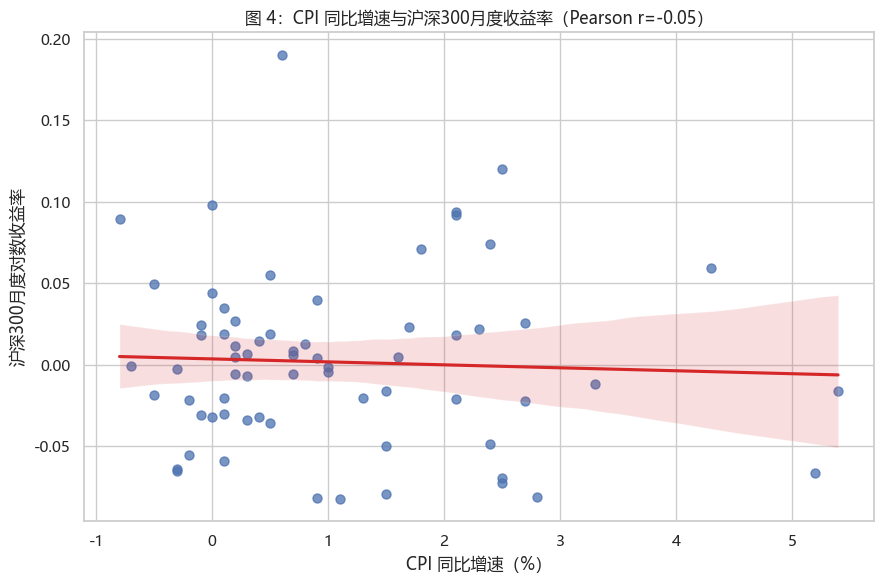

In [6]:
monthly = (
    combined.drop_duplicates("date")
    .set_index("date")
    .sort_index()[["hs300_close", "cpi", "m2"]]
    .resample("ME")
    .last()
)
monthly["hs300_monthly_return"] = np.log(monthly["hs300_close"] / monthly["hs300_close"].shift(1))
scatter = monthly.dropna(subset=["hs300_monthly_return", "cpi"])
pearson_r = scatter["cpi"].corr(scatter["hs300_monthly_return"])

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=scatter, x="cpi", y="hs300_monthly_return", ax=ax,
            scatter_kws={"s": 42, "alpha": 0.75}, line_kws={"color": "#d62728"})
ax.set_title(f"图 4：CPI 同比增速与沪深300月度收益率（Pearson r={pearson_r:.2f}）")
ax.set_xlabel("CPI 同比增速（%）")
ax.set_ylabel("沪深300月度对数收益率")
fig.tight_layout()
fig.savefig(OUTPUT / "fig4_macro_cpi_vs_hs300.png", dpi=180)
plt.show()


图 4 用散点和拟合线展示 CPI 与市场月度收益的线性关系。如果相关系数为正，说明样本期内较高通胀月份常伴随较高市场收益；如果为负，则可能反映通胀上行带来的政策收紧或估值压力。不过宏观变量与股票市场之间存在滞后和多因素共同作用，不能仅凭单变量散点图判断因果。


## 图 5（选做）：财务指标 ROE 跨公司对比


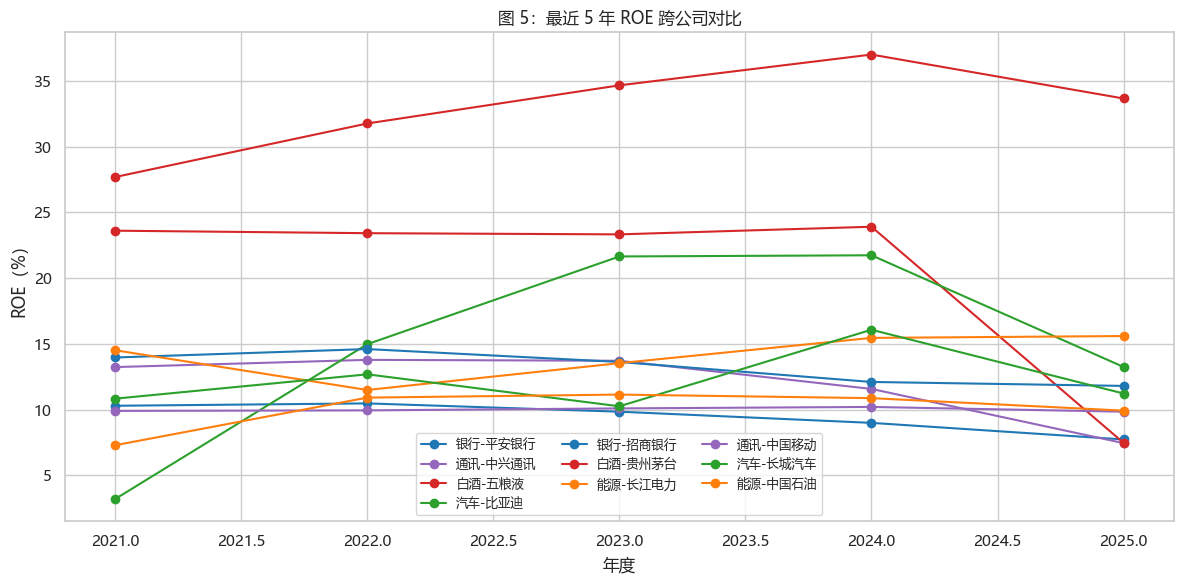

In [7]:
roe = finance[finance["indicator"] == "roe"].copy()
fig, ax = plt.subplots(figsize=(12, 6))
for code_value, group in roe.groupby("code"):
    meta = stock_info.loc[stock_info["code"].astype(str).str.zfill(6) == str(code_value).zfill(6)].iloc[0]
    ax.plot(group["year"], group["value"], marker="o", color=industry_palette[meta["industry"]], label=f"{meta['industry']}-{meta['name']}")
ax.set_title("图 5：最近 5 年 ROE 跨公司对比")
ax.set_xlabel("年度")
ax.set_ylabel("ROE（%）")
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT / "fig5_roe_comparison.png", dpi=180)
plt.show()


图 5 用 ROE 展示公司盈利能力差异。消费龙头通常 ROE 水平较高，公用事业和通讯运营商可能更稳定，汽车和通讯设备公司的 ROE 则更容易受产业周期、投资扩张和竞争格局影响。


## 5.1 CAPM 模型估计

CAPM 设定无风险利率为年化 2%，换算为日度 `0.02 / 252`。


In [8]:
RF_DAILY = 0.02 / 252
capm_records = []

for code_value, group in combined.groupby("code"):
    data = group[["return", "hs300_return"]].dropna().copy()
    data["excess_stock"] = data["return"] - RF_DAILY
    data["excess_market"] = data["hs300_return"] - RF_DAILY
    X = sm.add_constant(data["excess_market"])
    y = data["excess_stock"]
    model = sm.OLS(y, X).fit()
    ci = model.conf_int().loc["excess_market"]
    meta = stock_info.loc[stock_info["code"].astype(str).str.zfill(6) == str(code_value).zfill(6)].iloc[0]
    capm_records.append({
        "股票": meta["name"],
        "代码": str(code_value).zfill(6),
        "行业": meta["industry"],
        "alpha": model.params["const"],
        "alpha_pvalue": model.pvalues["const"],
        "beta": model.params["excess_market"],
        "beta_ci_low": ci[0],
        "beta_ci_high": ci[1],
        "r_squared": model.rsquared,
    })

capm_results = pd.DataFrame(capm_records).sort_values("beta", ascending=False)
capm_results.to_csv(OUTPUT / "capm_results.csv", index=False, encoding="utf-8-sig")
capm_results


,股票,代码,行业,alpha,alpha_pvalue,beta,beta_ci_low,beta_ci_high,r_squared
3,比亚迪,002594,汽车,0.001075,0.061908,1.274606,1.179361,1.369851,0.309537
1,中兴通讯,000063,通讯,-0.000040,0.943441,1.247095,1.152636,1.341554,0.303922
8,长城汽车,601633,汽车,0.000428,0.494764,1.175152,1.071348,1.278956,0.242898
2,五粮液,000858,白酒,-0.000210,0.564835,1.168443,1.108095,1.228792,0.484114
5,贵州茅台,600519,白酒,0.000102,0.741366,0.893367,0.842071,0.944664,0.431581
0,平安银行,000001,银行,-0.000239,0.480727,0.855568,0.799370,0.911767,0.367159
4,招商银行,600036,银行,0.000033,0.911587,0.748917,0.699930,0.797904,0.369114
9,中国石油,601857,能源,0.000537,0.233522,0.446139,0.371546,0.520731,0.082188
7,中国移动,600941,通讯,0.000627,0.184968,0.298104,0.215344,0.380864,0.045417
6,长江电力,600900,能源,0.000308,0.269781,0.224457,0.178387,0.270528,0.056470


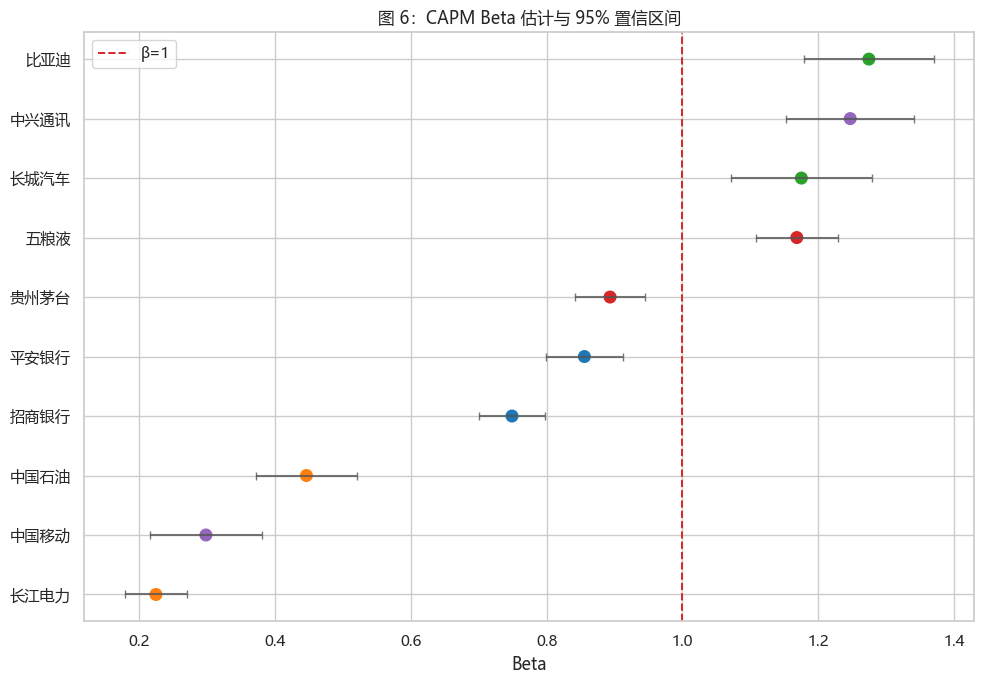

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_df = capm_results.sort_values("beta")
y_pos = np.arange(len(plot_df))
colors = plot_df["行业"].map(industry_palette)
xerr = np.vstack([
    plot_df["beta"] - plot_df["beta_ci_low"],
    plot_df["beta_ci_high"] - plot_df["beta"],
])
ax.errorbar(plot_df["beta"], y_pos, xerr=xerr, fmt="none", ecolor="#555555", capsize=3, alpha=0.8)
ax.scatter(plot_df["beta"], y_pos, c=colors, s=70)
ax.axvline(1.0, color="#d62728", linestyle="--", lw=1.4, label="β=1")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["股票"])
ax.set_xlabel("Beta")
ax.set_title("图 6：CAPM Beta 估计与 95% 置信区间")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / "fig6_capm_beta.png", dpi=180)
plt.show()


### CAPM 讨论


In [10]:
beta_gt_1 = capm_results[capm_results["beta"] > 1]
alpha_sig = capm_results[capm_results["alpha_pvalue"] < 0.05]
highest_r2 = capm_results.loc[capm_results["r_squared"].idxmax()]
lowest_r2 = capm_results.loc[capm_results["r_squared"].idxmin()]

print("1. Beta > 1 的股票：")
if beta_gt_1.empty:
    print("   样本中没有 Beta 明显大于 1 的股票，整体系统性风险暴露低于或接近市场。")
else:
    print("   " + "、".join([f"{r['股票']}（{r['行业']}，β={r['beta']:.2f}）" for _, r in beta_gt_1.iterrows()]))
    print("   汽车、通讯设备等成长或周期属性更强的行业若 Beta 较高，通常与其对经济景气、资本开支和风险偏好的敏感性相吻合。")

print("\n2. Alpha 显著性：")
if alpha_sig.empty:
    print("   没有股票 Alpha 在 5% 水平显著异于 0，说明控制市场风险后，样本中未发现稳定的超额收益。")
else:
    print("   " + "、".join([f"{r['股票']}（p={r['alpha_pvalue']:.3f}）" for _, r in alpha_sig.iterrows()]))
    print("   Alpha 显著意味着在 CAPM 的单因子框架下，该股票仍有不能被市场因子解释的平均超额收益，但还需结合样本期和其他风险因子判断。")

print("\n3. R² 差异：")
print(f"   R² 最高的是 {highest_r2['股票']}（{highest_r2['r_squared']:.2%}），最低的是 {lowest_r2['股票']}（{lowest_r2['r_squared']:.2%}）。")
print("   R² 较高说明个股收益更大比例可由市场组合解释；R² 较低说明公司特质因素、行业事件或 idiosyncratic 风险占比更高。")


1. Beta > 1 的股票：
   比亚迪（汽车，β=1.27）、中兴通讯（通讯，β=1.25）、长城汽车（汽车，β=1.18）、五粮液（白酒，β=1.17）
   汽车、通讯设备等成长或周期属性更强的行业若 Beta 较高，通常与其对经济景气、资本开支和风险偏好的敏感性相吻合。

2. Alpha 显著性：
   没有股票 Alpha 在 5% 水平显著异于 0，说明控制市场风险后，样本中未发现稳定的超额收益。

3. R² 差异：
   R² 最高的是 五粮液（48.41%），最低的是 中国移动（4.54%）。
   R² 较高说明个股收益更大比例可由市场组合解释；R² 较低说明公司特质因素、行业事件或 idiosyncratic 风险占比更高。


## 结论

本项目建立了从数据获取、清洗、存储、合并到统计分析和回归检验的完整流程。CSV 适合透明提交和检查，Parquet 更适合后续扩展到更大数据量；CAPM 结果则提供了比较不同行业系统性风险暴露的基础框架。
